In [5]:
!pip install mne
!pip install tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 54.4 MB/s eta 0:00:00


In [6]:
import random
import os
import pandas as pd
from tqdm.notebook import tqdm
from mne.datasets import eegbci
from mne.io import read_raw_edf
from mne import events_from_annotations, Epochs

In [3]:
# list of all subject_id [0-109]
random.seed(0)
subjects_ids = list(range(1, 110))
random.shuffle(subjects_ids)
num_subjects = len(subjects_ids)

assert num_subjects == 109

In [4]:
# setting up getting correct runs from MNE library
left_v_right_hand_MI_runs = [4, 8, 12]
hands_v_feet_MI_runs = [6, 10, 14]
all_MI_runs = left_v_right_hand_MI_runs + hands_v_feet_MI_runs
assert len(all_MI_runs) == len(left_v_right_hand_MI_runs) +

In [5]:
# function to load user run information
def load_user(subject_id: int, run: int, verbose:bool =False):
  """
  returns a mne.io.edf.edf.RawEDF associated to subject_id and run

  parameters:
  subject_id: int
  run: int
  verbose: bool

  returns:
  raw_list: mne.io.edf.edf.RawEDF
  """
  file_paths = eegbci.load_data(subjects=subject_id, runs=run, verbose=verbose)
  raw_list = [read_raw_edf(f, preload=True, verbose=verbose) for f in file_paths]
  return raw_list[0]

# Testing load_user()


Do you want to set the path:
    /root/mne_data
as the default EEGBCI dataset path in the mne-python config [y]/n? y
<class 'mne.io.edf.edf.RawEDF'>
20000
Using matplotlib as 2D backend.


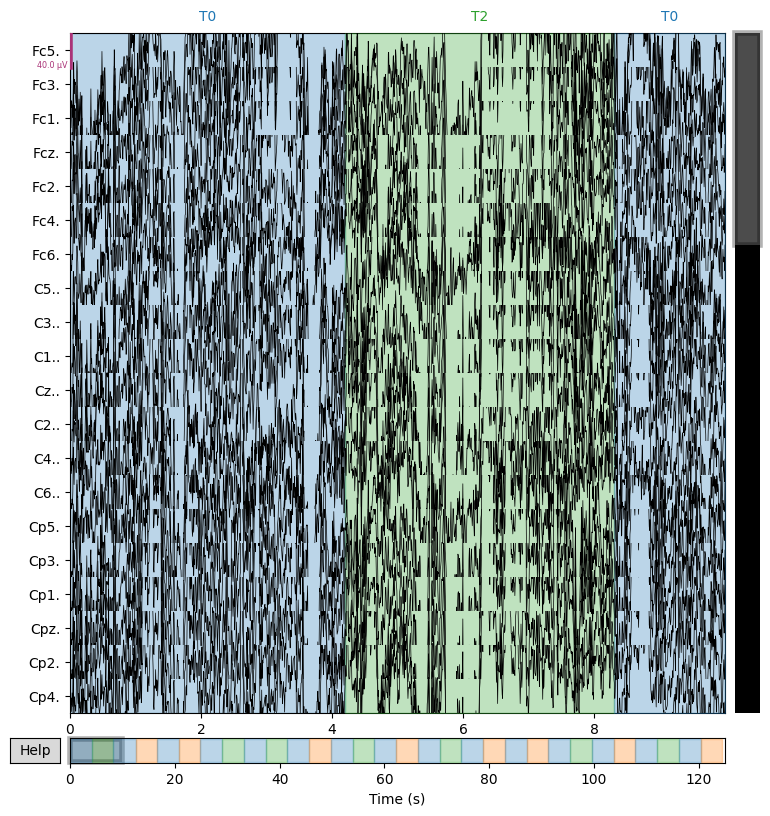

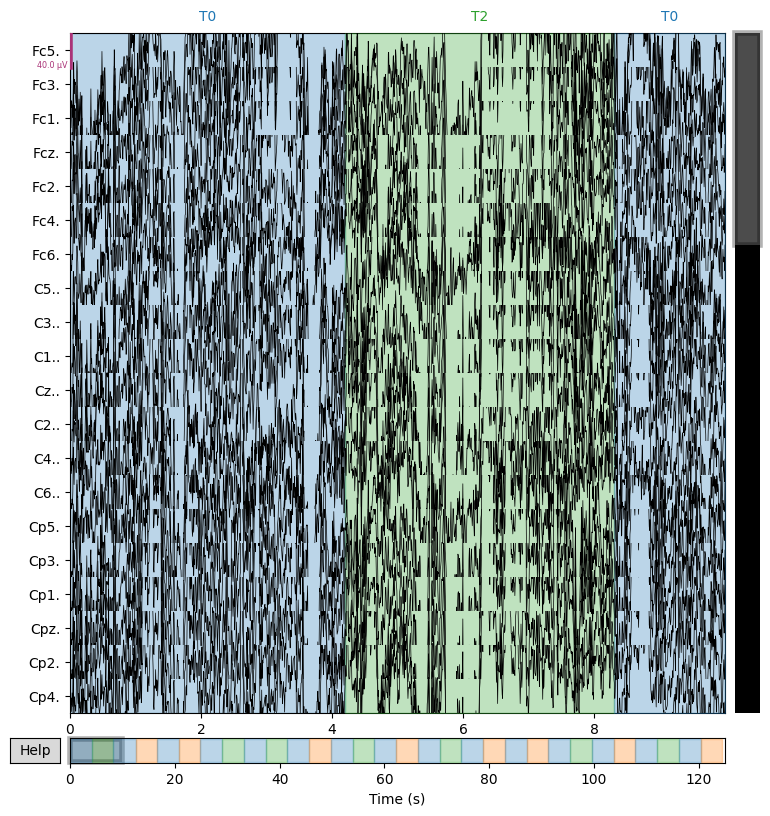

In [6]:
# testing load_user()
test_subject = 1
test_run = 4
test_raw = load_user(test_subject, test_run)
print(type(test_raw))
print(len(test_raw))
test_raw.plot()

# Building Train, Val, Test dataframes

In [7]:
# function that slices raw mne object
import mne
import numpy as np
def slice_raw_to_numpy(raw: mne.io.edf.edf.RawEDF, start_time:float, end_time:float):
  """
  Slices a raw MNE object from start_time to end_time and return numpy array

  Parameters:
  - raw: mne.io.edf.edf.RawEDF
  - start_time: float
  - end_time: float

  Returns:
  - numpy array
  """
  sfreq = raw.info['sfreq']
  start_sample = int(start_time * sfreq)
  end_sample = int(end_time * sfreq)

  data, _ = raw[:, start_sample:end_sample]
  return data


In [8]:
from typing import List

def process_subject(subject_id:int, runs:List[int]):
  """
  return a df for subject
  subject_id: int
  runs: list of int
  """

  # builds df
  subject_df = pd.DataFrame(columns=['subject_id', 'run', 'start_time', 'end_time', 'augmentation', 'X', 'label'])

  for run in runs:
    try:

        # defines label_map
      label_map = {
          'T0': 'rest',
          'T1': 'left_hand' if run in left_v_right_hand_MI_runs else 'both_hands',
          'T2': 'right_hand' if run in left_v_right_hand_MI_runs else 'both_feet'
      }

      # downloads users' eeg signals
      raw = load_user(subject_id, run)

      # epoching signals based on start_time and duration
      for onset, duration, desc in zip(raw.annotations.onset,
                                       raw.annotations.duration,
                                       raw.annotations.description):
        # slicing signal into X
        end_time = onset + duration
        x = slice_raw_to_numpy(raw, onset, end_time)

        # adding to df
        subject_df = pd.concat([subject_df, pd.DataFrame([{
            'subject_id': subject_id,
            'run':run,
            'start_time': onset,
            'end_time': end_time,
            'augmentation': 'none',
            'X': x,
            'label': label_map[desc]
        }])], ignore_index=True)


    except Exception as e:
      print(f"Subject {subject_id} (run {run}) failed: {e}")
  return subject_df


# Testing Process Subject Function

In [9]:
# # testing process_subject
## this is going to be done by ensuring that the number of annotations in raw == length of df of 1 subject on 1 run
test_subject = 1
test_run = 4
test_raw = load_user(test_subject, test_run)
test_df = process_subject(test_subject, [test_run])

assert len(test_raw.annotations.onset) == len(test_df)

/tmp/ipython-input-8-3445290296.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  subject_df = pd.concat([subject_df, pd.DataFrame([{


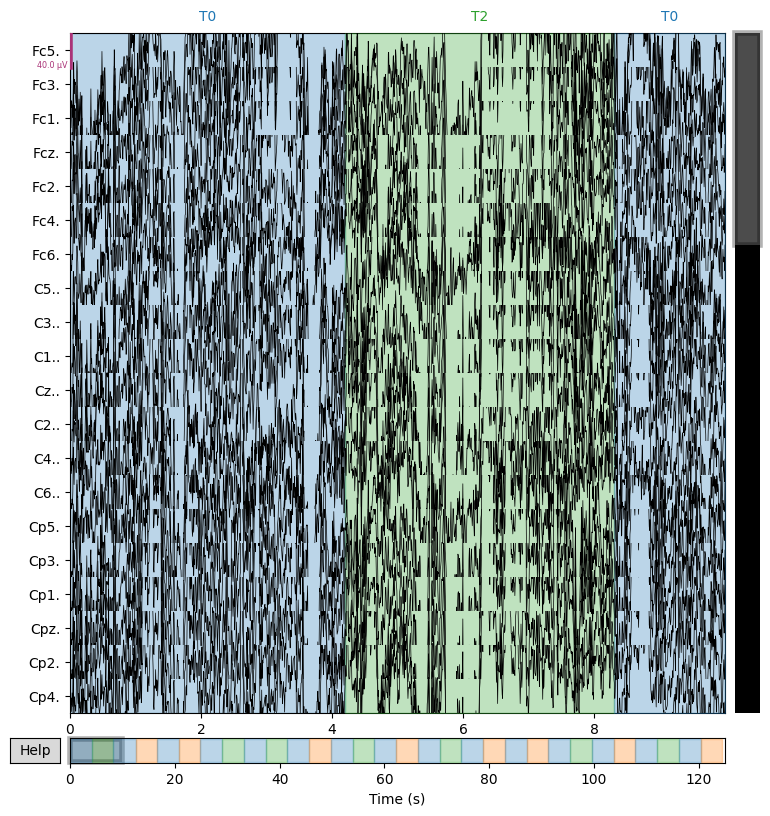

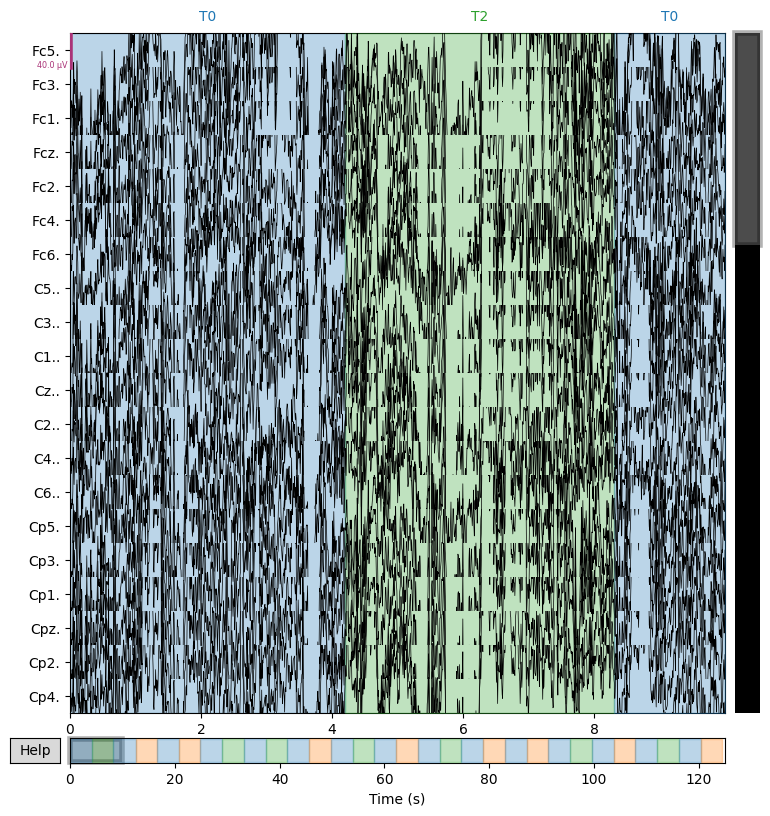

In [10]:
test_raw.plot()

In [11]:
test_df.head()

,subject_id,run,start_time,end_time,augmentation,X,label
0,1,4,0.0,4.2,none,"[[-4.9999999999999996e-06, -1.2e-05, -7.7e-05,...",rest
1,1,4,4.2,8.3,none,"[[-2.4999999999999998e-05, -1.6e-05, 7e-06, 3....",right_hand
2,1,4,8.3,12.5,none,"[[6.2e-05, -2.4e-05, -2.9999999999999997e-05, ...",rest
3,1,4,12.5,16.6,none,"[[-1.8e-05, -6e-06, 1e-06, -1.6e-05, 3e-06, -6...",left_hand
4,1,4,16.6,20.8,none,"[[-0.000127, -0.000121, -0.0001229999999999999...",rest


# Building and Saving of Dataframes

In [12]:
# splits_map = {
#     'train': train_ids,
#     'val': val_ids,
#     'test': test_ids
# }

In [2]:
# mount to google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Directory to save file
drive_path = "/content/drive/MyDrive/Colab Notebooks/StackedDataAugmentation/physionetdata"
os.makedirs(drive_path, exist_ok=True)

NameError: name 'os' is not defined

In [11]:
%cd /content/drive/MyDrive/Colab Notebooks/StackedDataAugmentation
!ls

/content/drive/MyDrive/Colab Notebooks/StackedDataAugmentation
arl-eegmodels		       EEGNoiseAndTimeTransformations.ipynb
EEGMMIDBDatasetLoaderV2.ipynb  EEGNoiseAndTimeTransformations.py
EEGMMIDBDatasetLoaderV2.py     GANTraining
EEGMMIDBDatasetLoaderV3.ipynb  physionetdata
EEGMMIDBSignalV6.ipynb	       __pycache__
EEGModels.py		       saved_eegnet_models
eegnet_eval_results.csv        StackedDataAugmentationTraining.ipynb


In [16]:
all_df = pd.DataFrame()
for subject_id in tqdm(subjects_ids, desc=f'Processing Subjects'):
  df = process_subject(subject_id, all_MI_runs)
  all_df = pd.concat([all_df, df], ignore_index=True)
print("Finished")


Processing Subjects:   0%|          | 0/109 [00:00<?, ?it/s]

Streaming output truncated to the last 5000 lines.
/tmp/ipython-input-8-3445290296.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  subject_df = pd.concat([subject_df, pd.DataFrame([{
/tmp/ipython-input-8-3445290296.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  subject_df = pd.concat([subject_df, pd.DataFrame([{
/tmp/ipython-input-8-3445290296.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no lon

Finished


/usr/lib/python3.11/contextlib.py:137: RuntimeWarning: Could not acquire lock file after 5 seconds, consider deleting it if you know the corresponding file is usable:
/root/.mne/mne-python.json.lock
  return next(self.gen)


# Loading df

In [7]:
# loading all_df
all_df = pd.read_pickle(f'{drive_path}/eegmmidb_all_df.pkl')

# Preprocessing

## Remove Subject recordings where timing is more than 4.5 and less than 3.5

In [7]:
# find subjects where end-start diff is not around 4 seconds
df_rows_to_drop = []
for i, row in all_df.iterrows():
  diff = row['end_time'] - row['start_time']
  if diff > 4.5 or diff < 3.5:
    df_rows_to_drop.append(i)


In [9]:
# print ids of subjects whose recordings are getting dropped
unique_ids_to_drop = set()
for i in df_rows_to_drop:
  unique_ids_to_drop.add(all_df.loc[i, 'subject_id'])

print(unique_ids_to_drop)
# this ended up dropping users: {100, 88, 92, 104}

{100, 88, 92, 104}


In [10]:
# drop df_rows_to_drop
all_df = all_df.drop(df_rows_to_drop)

In [11]:
# pickle all_df to drive
all_df.to_pickle(f'{drive_path}/eegmmidb_all_df.pkl')

## Balancing Dataset Labels

In [8]:
# count number of each label
label_counts = all_df['label'].value_counts()
print(label_counts)

label
rest          9538
left_hand     2405
both_hands    2388
both_feet     2382
right_hand    2362
Name: count, dtype: int64


In [9]:
# reduce number of rest to 2400
rest_df = all_df[all_df['label'] == 'rest']
rest_df = rest_df.sample(n=2400, random_state=0)

# only keep rest_df from all_df
all_df = all_df[all_df['label'] != 'rest']

# concat all_df with rest_df
all_df = pd.concat([all_df, rest_df], ignore_index=True)

# count number of each label
label_counts = all_df['label'].value_counts()
print(label_counts)

label
left_hand     2405
rest          2400
both_hands    2388
both_feet     2382
right_hand    2362
Name: count, dtype: int64


# Doing subject wise split on all_df to train_df, val_df, and test_df



In [10]:
# list of all subject_id [0-109]
random.seed(0)
subjects_ids = list(range(1, 110))

# drop unique_ids_to_drop
unique_ids_to_drop = {100, 88, 92, 104}
subjects_ids = [x for x in subjects_ids if x not in unique_ids_to_drop]

# shuffle subject_ids
random.shuffle(subjects_ids)
num_subjects = len(subjects_ids)

# setting up the random splitting for train, val, test
percent_train = 0.7
percent_val = 0.15
percent_test = 0.15

num_train = int(percent_train * num_subjects)
num_val = int(percent_val * num_subjects)
num_test = num_subjects - num_train - num_val

# splitting subject_ids to appropriate location
train_ids = subjects_ids[:num_train]
val_ids = subjects_ids[num_train: num_train + num_val]
test_ids = subjects_ids[num_train + num_val:]

# verifying that there's 109 subjects
assert num_train + num_val + num_test == num_subjects
assert len(train_ids) + len(val_ids) + len(test_ids) == num_subjects
## veryfing there's no intesection between ids
assert len(set(train_ids).intersection(val_ids)) == 0
assert len(set(train_ids).intersection(test_ids)) == 0
assert len(set(val_ids).intersection(test_ids)) == 0

assert num_subjects == 109 - len(unique_ids_to_drop)

In [11]:
print(train_ids)
print(val_ids)
print(test_ids)

[31, 64, 38, 9, 94, 25, 17, 85, 24, 45, 55, 14, 30, 108, 109, 103, 95, 48, 3, 44, 42, 74, 84, 36, 68, 70, 77, 11, 90, 4, 23, 83, 20, 7, 59, 86, 49, 99, 106, 29, 35, 87, 58, 15, 91, 76, 5, 60, 21, 102, 16, 22, 32, 82, 1, 73, 79, 51, 53, 96, 26, 107, 47, 12, 2, 8, 105, 67, 57, 98, 71, 27, 41]
[56, 97, 81, 72, 61, 43, 10, 89, 40, 19, 78, 69, 33, 80, 13]
[93, 37, 18, 65, 28, 75, 46, 62, 39, 52, 63, 66, 34, 6, 54, 101, 50]


In [12]:
train_df = all_df[all_df['subject_id'].isin(train_ids)].reset_index(drop=True)
val_df = all_df[all_df['subject_id'].isin(val_ids)].reset_index(drop=True)
test_df = all_df[all_df['subject_id'].isin(test_ids)].reset_index(drop=True)

In [13]:
# print ids of all df
print(train_df['subject_id'].unique())
print(val_df['subject_id'].unique())
print(test_df['subject_id'].unique())

[24 103 4 74 55 45 25 102 82 30 95 70 96 17 31 51 9 68 23 42 90 108 38 44
 11 106 26 76 3 48 14 49 85 86 36 20 7 32 58 59 105 29 35 83 60 15 79 5 73
 87 21 47 16 22 77 53 64 1 12 2 8 67 57 99 71 27 41 107 84 91 94 98 109]
[97 81 89 56 72 61 43 10 40 19 78 69 33 80 13]
[93 101 37 18 65 28 75 46 62 39 52 63 66 34 6 54 50]


In [17]:
# see label amount for train_df
print(train_df['label'].value_counts())

label
left_hand     1656
rest          1652
both_hands    1644
both_feet     1641
right_hand    1629
Name: count, dtype: int64


In [14]:
# save train_df, val_df and test_df to path
train_df.to_pickle(f'{drive_path}/eegmmidb_train_df.pkl')
val_df.to_pickle(f'{drive_path}/eegmmidb_val_df.pkl')
test_df.to_pickle(f'{drive_path}/eegmmidb_test_df.pkl')
print('Finished')

Finished
